<div style="background-color:#ffecd2; color:#0f0c29; text-align:center; padding:15px; font-size:23px; border-radius:25px;">CREDIT DEFAULT PREDICTION SYSTEM</div>

### Importing required libararies

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, TargetEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score, confusion_matrix

### Data Collection 

In [4]:
pd.set_option('display.max_columns',None) # Showing all columns
df = pd.read_csv(r'C:\Users\Dell\Downloads\default of credit card clients.csv', encoding = 'latin-1') # Importing dataset
df

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29996,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29997,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0
29998,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29999,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


##### # Data have column names which are not much meaningful

### Renaming feature names

In [5]:
df = df.rename(columns = {'X1' : 'Limit_Bal','X2' : 'Gender' , 'X3' : 'Education' , 'X4' : 'Marital Status', 'X5': 'Age','X6' : 'Sep_Delay','X7' : 'Aug_Delay','X8' : 'Jul_Delay','X9' : 'Jun_Delay','X10' : 'May_Delay','X11' : 'Apr_Delay','X12' : 'Bill_Gen_Sep','X13': 'Bill_Gen_Aug','X14': 'Bill_Gen_Jul','X15' :'Bill_Gen_Jun','X16' :'Bill_Gen_May','X17' :'Bill_Gen_Apr','X18' :'Amt_Paid_Sep','X19': 'Amt_Paid_Aug','X20' : 'Amt_Paid_Jul','X21': 'Amt_Paid_Jun','X22' :'Amt_Paid_May','X23' :'Amt_Paid_Apr','Y' :'Is_Default'})

### Removing unnecessary rows and columns

In [6]:
df.drop(columns  = ['Unnamed: 0'],inplace= True) # Removing columns
df.drop(0, inplace = True)

### Data Inspection

In [7]:
df.info() # Checking for datatypes and null values

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Limit_Bal       30000 non-null  str  
 1   Gender          30000 non-null  str  
 2   Education       30000 non-null  str  
 3   Marital Status  30000 non-null  str  
 4   Age             30000 non-null  str  
 5   Sep_Delay       30000 non-null  str  
 6   Aug_Delay       30000 non-null  str  
 7   Jul_Delay       30000 non-null  str  
 8   Jun_Delay       30000 non-null  str  
 9   May_Delay       30000 non-null  str  
 10  Apr_Delay       30000 non-null  str  
 11  Bill_Gen_Sep    30000 non-null  str  
 12  Bill_Gen_Aug    30000 non-null  str  
 13  Bill_Gen_Jul    30000 non-null  str  
 14  Bill_Gen_Jun    30000 non-null  str  
 15  Bill_Gen_May    30000 non-null  str  
 16  Bill_Gen_Apr    30000 non-null  str  
 17  Amt_Paid_Sep    30000 non-null  str  
 18  Amt_Paid_Aug    30000 non-null  str  

##### # Data have incorrect datatypes

In [8]:
df.describe() # Getting numerical information

,Limit_Bal,Gender,Education,Marital Status,Age,Sep_Delay,Aug_Delay,Jul_Delay,Jun_Delay,May_Delay,Apr_Delay,Bill_Gen_Sep,Bill_Gen_Aug,Bill_Gen_Jul,Bill_Gen_Jun,Bill_Gen_May,Bill_Gen_Apr,Amt_Paid_Sep,Amt_Paid_Aug,Amt_Paid_Jul,Amt_Paid_Jun,Amt_Paid_May,Amt_Paid_Apr,Is_Default
count,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000
unique,81,2,7,4,56,11,11,11,11,10,10,22723,22346,22026,21548,21010,20604,7943,7899,7518,6937,6897,6939,2
top,50000,2,2,2,29,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
freq,3365,18112,14030,15964,1605,14737,15730,15764,16455,16947,16286,2008,2506,2870,3195,3506,4020,5249,5396,5968,6408,6703,7173,23364


##### # Info is not much useful because of incorrect datatypes

In [9]:
df.isnull().sum() # Checking null values 

Limit_Bal         0
Gender            0
Education         0
Marital Status    0
Age               0
Sep_Delay         0
Aug_Delay         0
Jul_Delay         0
Jun_Delay         0
May_Delay         0
Apr_Delay         0
Bill_Gen_Sep      0
Bill_Gen_Aug      0
Bill_Gen_Jul      0
Bill_Gen_Jun      0
Bill_Gen_May      0
Bill_Gen_Apr      0
Amt_Paid_Sep      0
Amt_Paid_Aug      0
Amt_Paid_Jul      0
Amt_Paid_Jun      0
Amt_Paid_May      0
Amt_Paid_Apr      0
Is_Default        0
dtype: int64

##### # There is no missing values in the data

In [10]:
df.duplicated().sum() # Checking for duplicated rows

np.int64(35)

In [11]:
for col in df.columns:     # Checking for unique values counts
    if df[col].nunique() < 50:
        print(f'Col Name: {col}')
        print(df[col].value_counts())
        print('-' * 50)


Col Name: Gender
Gender
2    18112
1    11888
Name: count, dtype: int64
--------------------------------------------------
Col Name: Education
Education
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
--------------------------------------------------
Col Name: Marital Status
Marital Status
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64
--------------------------------------------------
Col Name: Sep_Delay
Sep_Delay
0     14737
-1     5686
1      3688
-2     2759
2      2667
3       322
4        76
5        26
8        19
6        11
7         9
Name: count, dtype: int64
--------------------------------------------------
Col Name: Aug_Delay
Aug_Delay
0     15730
-1     6050
2      3927
-2     3782
3       326
4        99
1        28
5        25
7        20
6        12
8         1
Name: count, dtype: int64
--------------------------------------------------
Col Name: Jul_Delay
Jul_Delay
0     15764
-1     5938


### Correcting Datatypes

In [12]:
for col in df.columns: # Converting datatypes of each columns to integer
    df[col] = df[col].astype(int)

### Handling Inconsistent Formatting

In [13]:
df['Marital Status'] = df['Marital Status'].replace({0 : 3})
df['Education'] = df['Education'].replace({5:4, 6:4})
df = df[df['Education'] != 0]

### Removing Duplicate Values

In [14]:
df.drop_duplicates(keep = 'first',inplace = True) # Remoing duplicated rows from the dataset

### Handling Outliers

In [15]:
df.describe().round() # Getting numerical information about features

,Limit_Bal,Gender,Education,Marital Status,Age,Sep_Delay,Aug_Delay,Jul_Delay,Jun_Delay,May_Delay,Apr_Delay,Bill_Gen_Sep,Bill_Gen_Aug,Bill_Gen_Jul,Bill_Gen_Jun,Bill_Gen_May,Bill_Gen_Apr,Amt_Paid_Sep,Amt_Paid_Aug,Amt_Paid_Jul,Amt_Paid_Jun,Amt_Paid_May,Amt_Paid_Apr,Is_Default
count,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0,29951.0
mean,167419.0,2.0,2.0,2.0,35.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,51301.0,49255.0,47082.0,43327.0,40374.0,38933.0,5670.0,5925.0,5230.0,4832.0,4806.0,5223.0,0.0
std,129773.0,0.0,1.0,1.0,9.0,1.0,1.0,1.0,1.0,1.0,1.0,73670.0,71207.0,69383.0,64364.0,60827.0,59583.0,16575.0,23053.0,17619.0,15678.0,15290.0,17791.0,0.0
min,10000.0,1.0,1.0,1.0,21.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-165580.0,-69777.0,-157264.0,-170000.0,-81334.0,-339603.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,50000.0,1.0,1.0,1.0,28.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,3598.0,3018.0,2712.0,2360.0,1792.0,1266.0,1000.0,850.0,390.0,300.0,261.0,132.0,0.0
50%,140000.0,2.0,2.0,2.0,34.0,0.0,0.0,0.0,0.0,0.0,0.0,22453.0,21333.0,20148.0,19087.0,18135.0,17133.0,2102.0,2010.0,1804.0,1500.0,1500.0,1500.0,0.0
75%,240000.0,2.0,2.0,2.0,41.0,0.0,0.0,0.0,0.0,0.0,0.0,67274.0,64137.0,60230.0,54610.0,50267.0,49270.0,5007.0,5000.0,4512.0,4016.0,4042.0,4000.0,0.0
max,1000000.0,2.0,4.0,3.0,79.0,8.0,8.0,8.0,8.0,8.0,8.0,964511.0,983931.0,1664089.0,891586.0,927171.0,961664.0,873552.0,1684259.0,896040.0,621000.0,426529.0,528666.0,1.0


##### # There are negative values in generated bills but maximum values are looking like genuine 

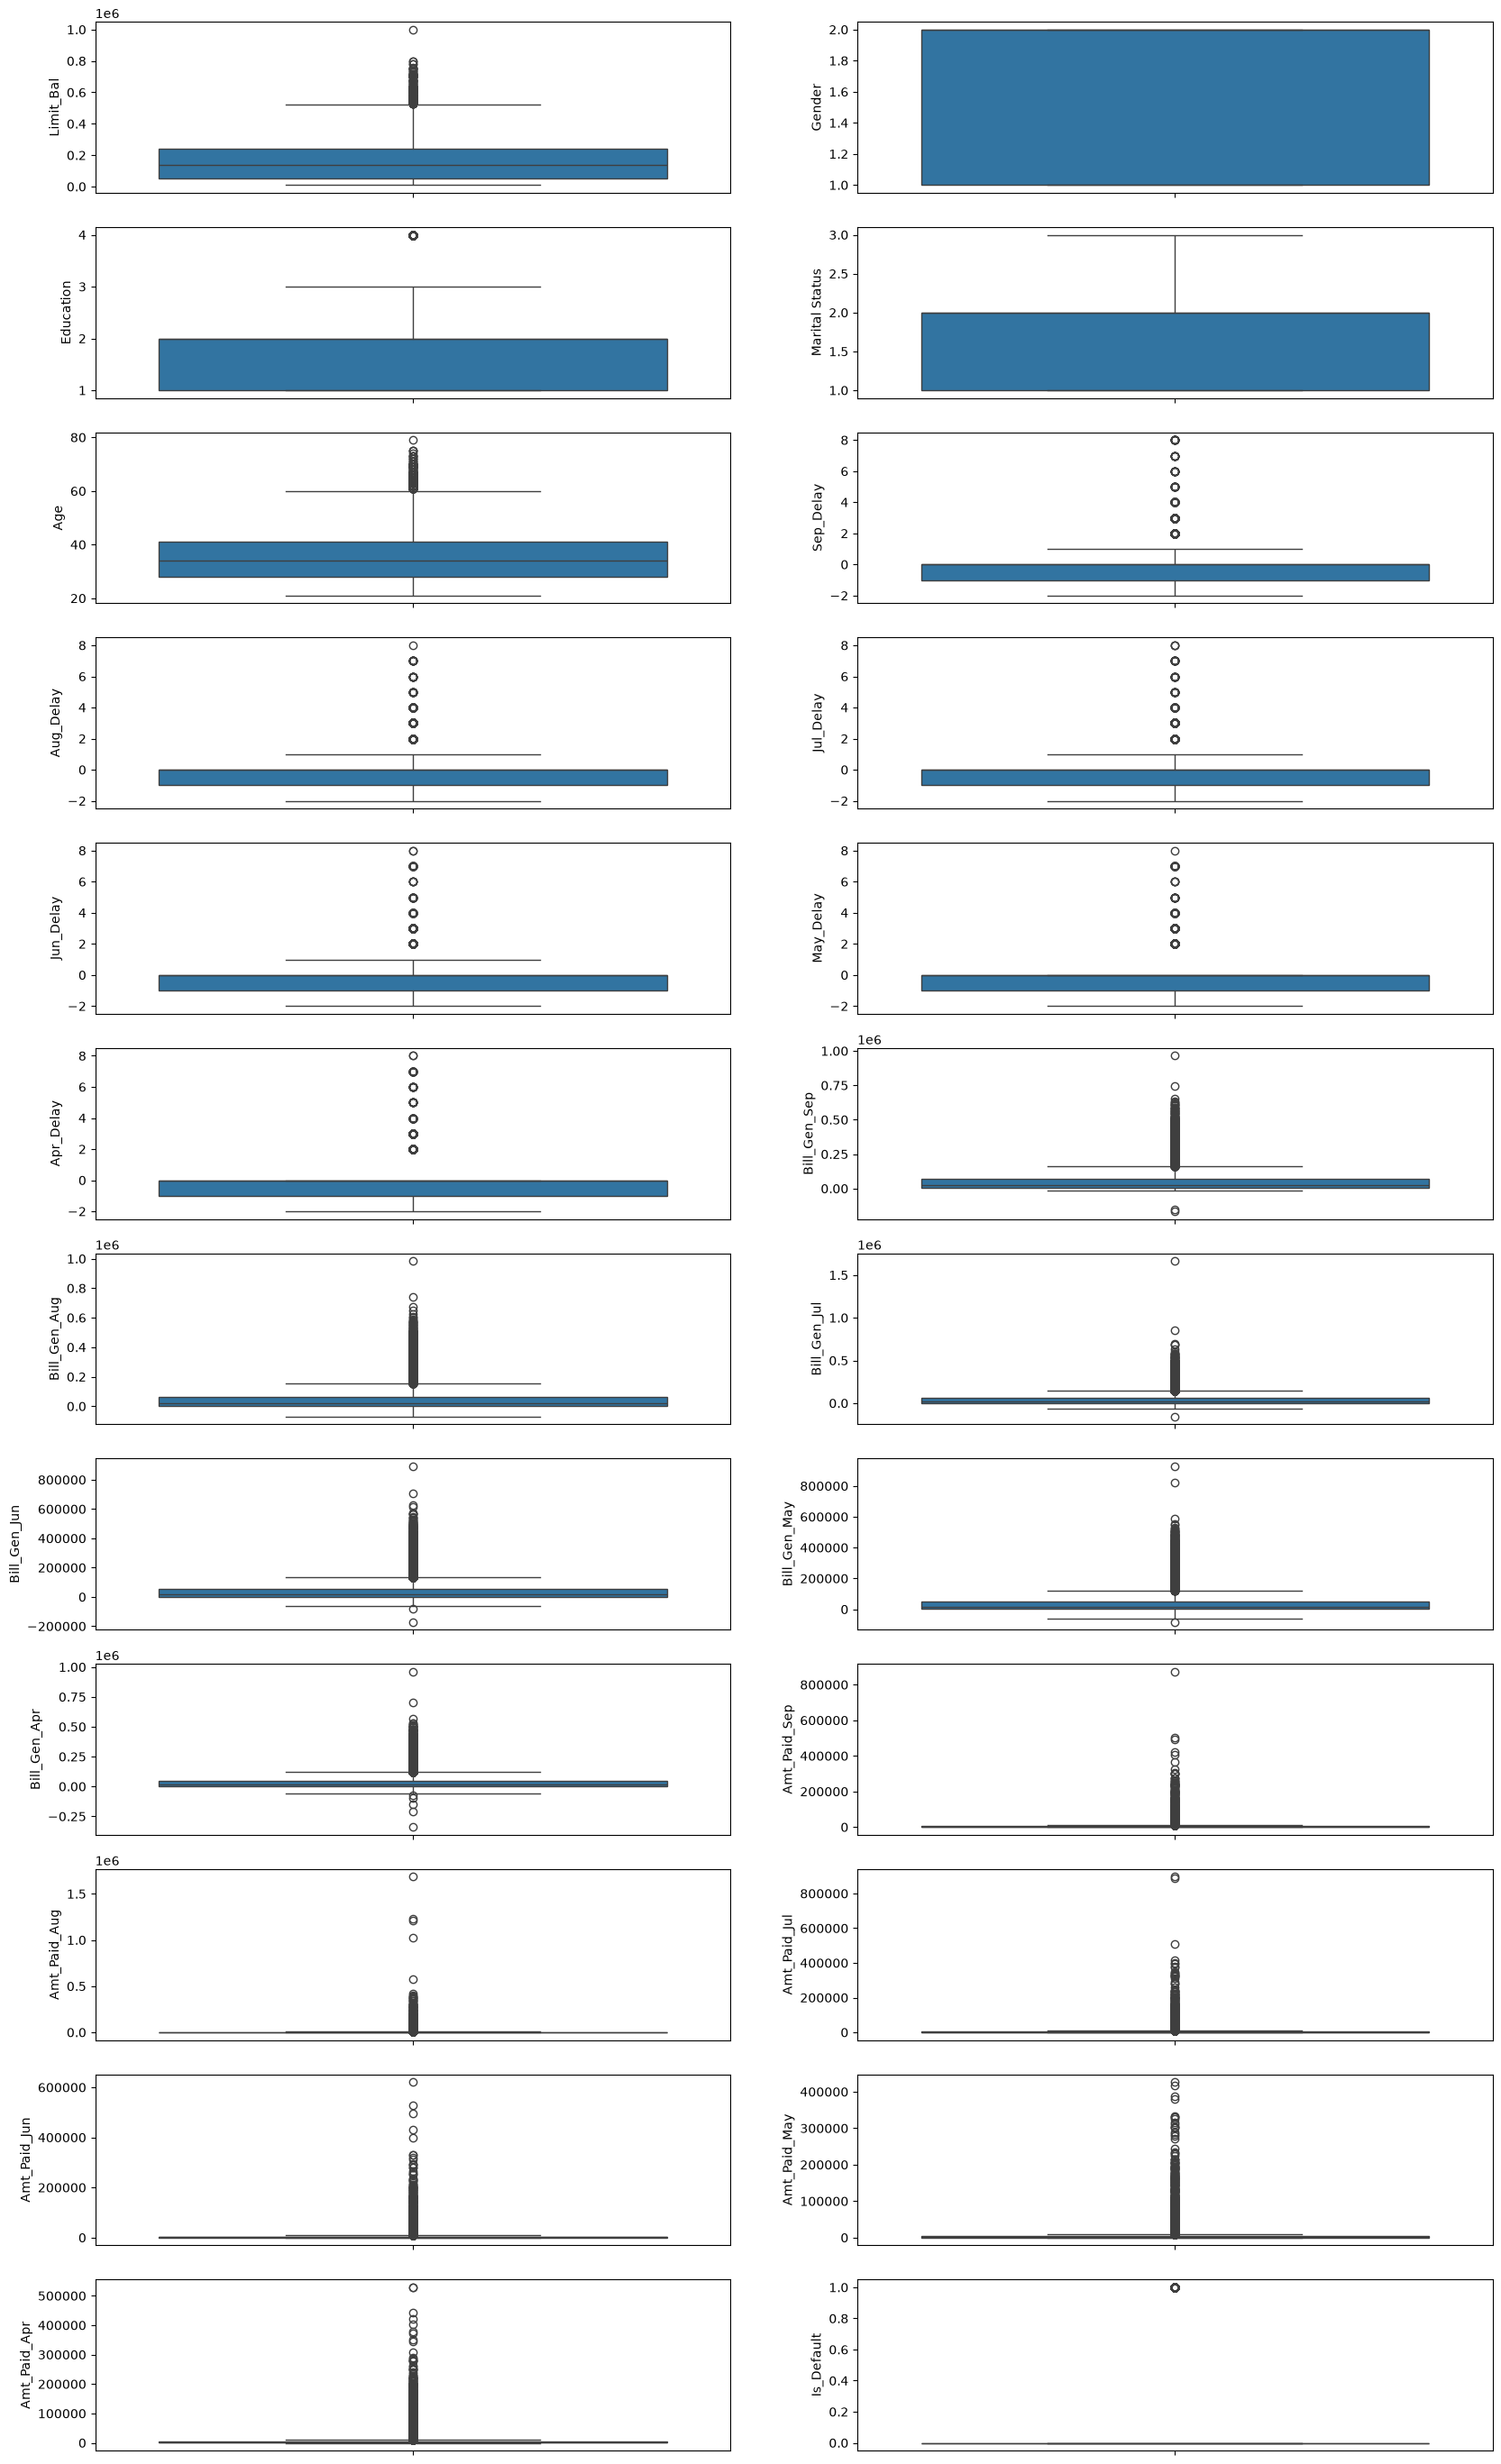

In [16]:
plt.figure(figsize = (20,35)) # Plotting boxplots to see outliers
for i, col in enumerate(df.columns,1):
    plt.subplot(12,2,i)
    sns.boxplot(df[col])


##### # Replacing negative bill generated with 0 because negative values may indicate repayment or exceed amount paid which means no bill generated and storing data about negative bill generated in a new feature

In [17]:
cols = ['Bill_Gen_Sep','Bill_Gen_Aug','Bill_Gen_Jul','Bill_Gen_Jun','Bill_Gen_May','Bill_Gen_Apr']

df['Negative_Bill_Count'] = (df[cols] < 0).sum(axis = 1) # Creating feature which stores number of months of getting negative bill

for col in cols:
    df.loc[df[col] < 0,col] = np.int64(0) # Replacing negative bill with 

features = ['Limit_Bal', 'Gender', 'Education', 'Marital Status', 'Age',
       'Sep_Delay', 'Aug_Delay', 'Jul_Delay', 'Jun_Delay', 'May_Delay',
       'Apr_Delay', 'Bill_Gen_Sep', 'Bill_Gen_Aug', 'Bill_Gen_Jul',
       'Bill_Gen_Jun', 'Bill_Gen_May', 'Bill_Gen_Apr', 'Amt_Paid_Sep',
       'Amt_Paid_Aug', 'Amt_Paid_Jul', 'Amt_Paid_Jun', 'Amt_Paid_May',
       'Amt_Paid_Apr', 'Negative_Bill_Count']


In [18]:
df['Negative_Bill_Count'].value_counts()

Negative_Bill_Count
0    28021
1      993
2      412
3      240
4      118
6       88
5       79
Name: count, dtype: int64

##### # Checking for negative bills after removing them

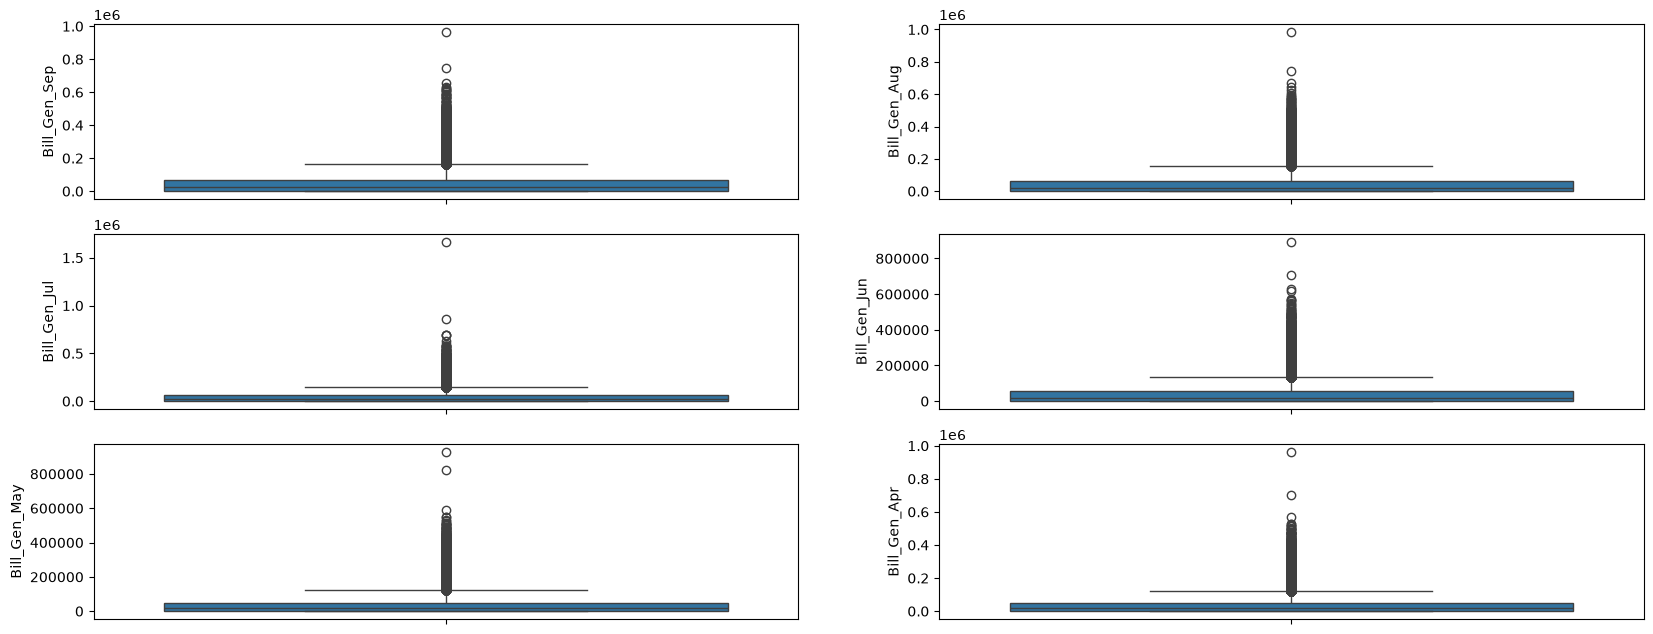

In [19]:
plt.figure(figsize = (20,35)) # Plotting boxplots to see outliers
for i, col in enumerate(cols,1):
    plt.subplot(13,2,i)
    sns.boxplot(df[col])

##### # Now, there is not any negative bill

### EDA ( Exploratory Data Analysis)

In [20]:
def number_format(number,pos): # Number formatter for million and thousands
    if number >= 1e6:
        return f'{(number/1e6):.1f} M'
    elif number >= 1e3:
        return f'{(number/1e3):.1f} K'
    else:
        return f'{number}'

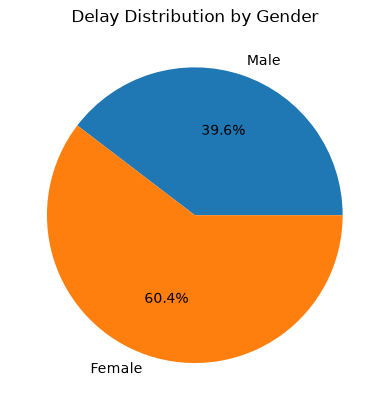

In [21]:
plt.pie(df.groupby('Gender')['Is_Default'].count(),labels = ['Male','Female'],autopct=  '%1.1f%%') 
plt.title('Delay Distribution by Gender')
plt.show()

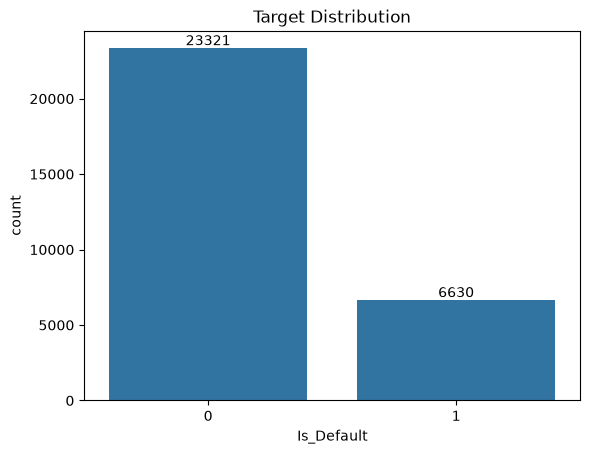

In [22]:
ax = sns.countplot(x = 'Is_Default',data = df)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Target Distribution')
plt.show()

In [23]:
(df['Is_Default'].value_counts(normalize= True) * 100).reset_index()

,Is_Default,proportion
0,0,77.863844
1,1,22.136156


##### # Data is imbalanced

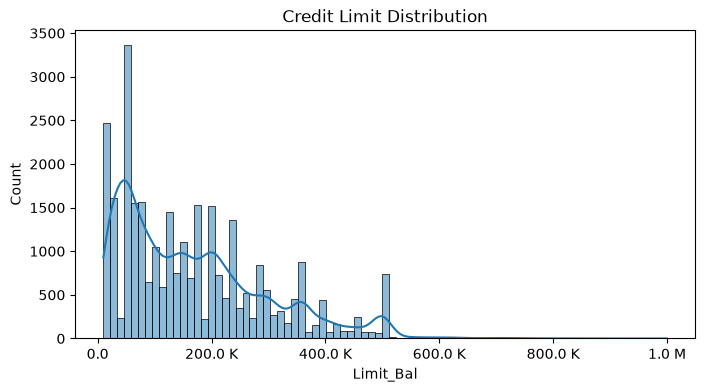

In [24]:
plt.figure(figsize=(8,4))

ax = sns.histplot(
    x='Limit_Bal',
    data=df,
    kde=True
)

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(number_format)
)

plt.title('Credit Limit Distribution')
plt.show()

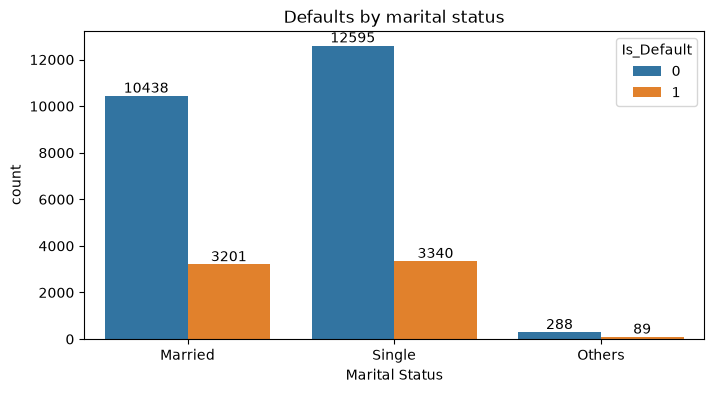

In [25]:
plt.figure(figsize = (8,4))
ax = sns.countplot(x = 'Marital Status', data = df,order = [1,2,3],hue = 'Is_Default')
for container in ax.containers:
    ax.bar_label(container)
ax.set_xticks([0,1,2])
ax.set_xticklabels(['Married','Single','Others'])
plt.title('Defaults by marital status')
plt.show()

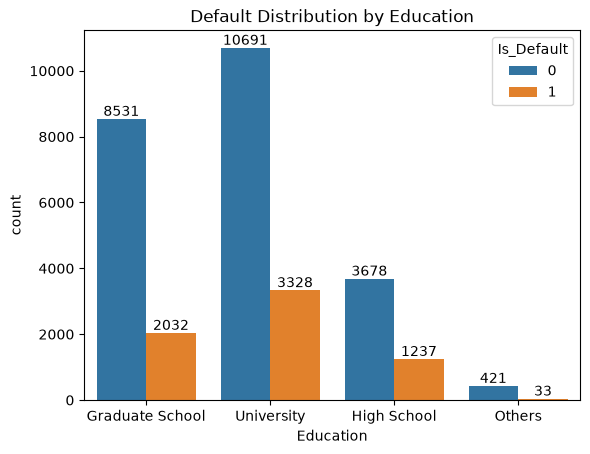

In [26]:
ax = sns.countplot(x = 'Education',data = df,hue = 'Is_Default')
for container in ax.containers:
    ax.bar_label(container)
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['Graduate School','University','High School','Others'])
plt.title('Default Distribution by Education')
plt.show()


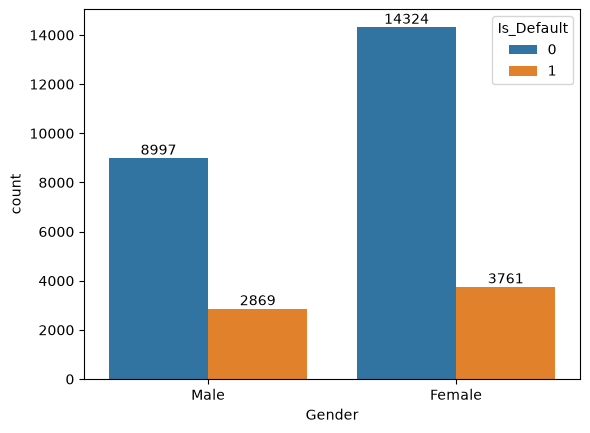

In [27]:
ax = sns.countplot(x='Gender', hue='Is_Default', data=df)
for container in ax.containers:
    ax.bar_label(container)
ax.set_xticks([0,1])
ax.set_xticklabels(['Male','Female'])
plt.show()


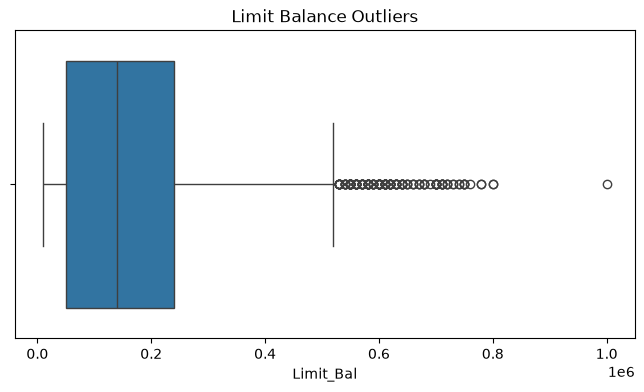

In [28]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Limit_Bal'])

plt.title('Limit Balance Outliers')
plt.show()

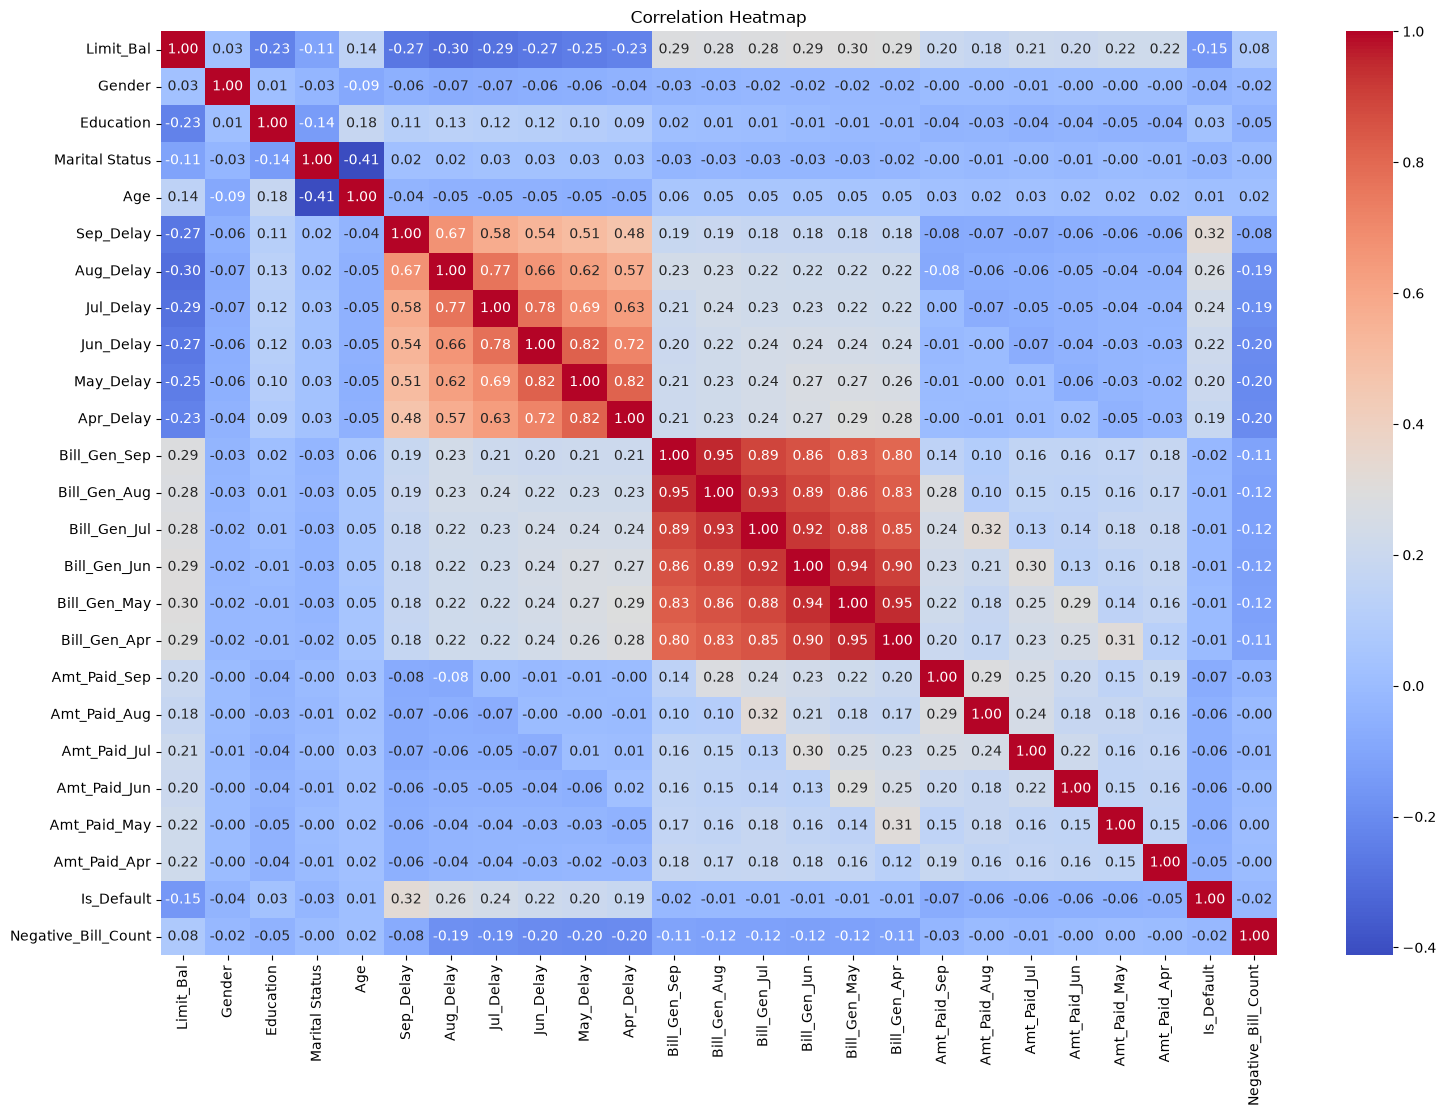

In [29]:
plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

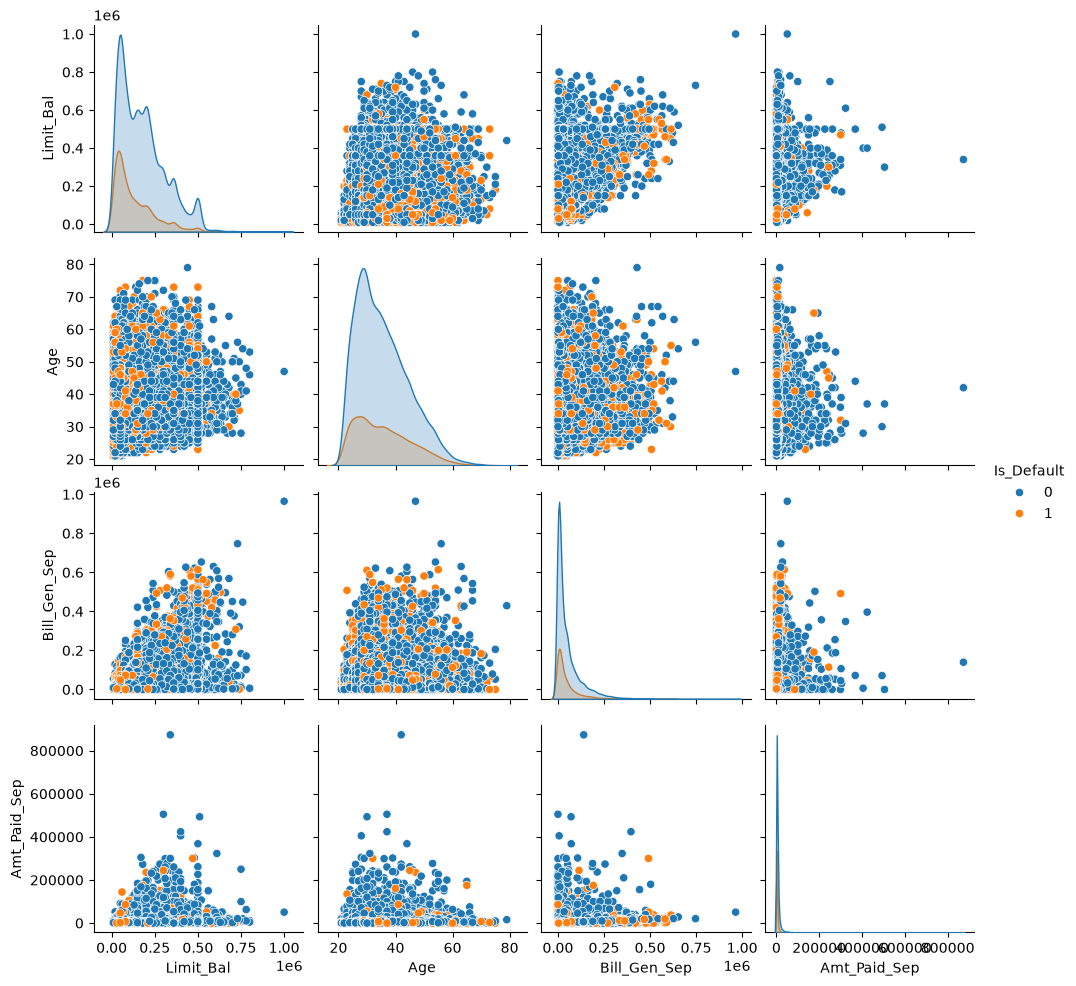

In [30]:
sns.pairplot(df[['Limit_Bal',
            'Age',
            'Bill_Gen_Sep',
            'Amt_Paid_Sep',
            'Is_Default']], hue = 'Is_Default')

<Axes: xlabel='Is_Default', ylabel='Limit_Bal'>

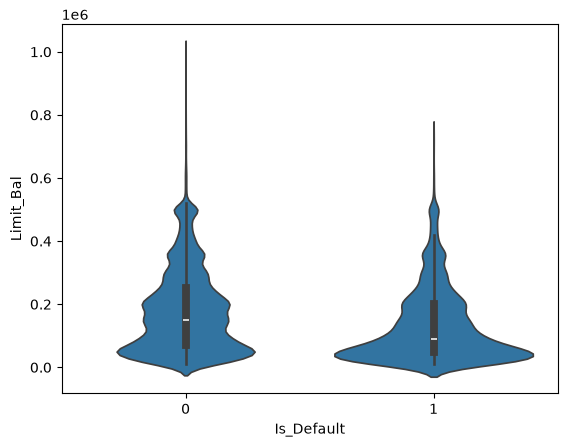

In [31]:
sns.violinplot(
    x='Is_Default',
    y='Limit_Bal',
    data=df
)

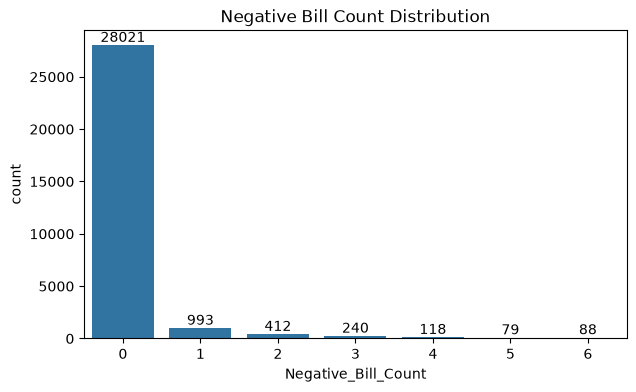

In [32]:
plt.figure(figsize = (7,4))
ax = sns.countplot(x = 'Negative_Bill_Count', data = df)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Negative Bill Count Distribution')
plt.show()


### Feature Engineering

In [33]:
df['Total_Bill'] = ((df[[ 'Bill_Gen_Sep', 'Bill_Gen_Aug', 'Bill_Gen_Jul',
       'Bill_Gen_Jun', 'Bill_Gen_May', 'Bill_Gen_Apr']].sum(axis = 1))).round(2)

df['Total_Pay'] = ((df[[ 'Amt_Paid_Sep',
       'Amt_Paid_Aug', 'Amt_Paid_Jul', 'Amt_Paid_Jun', 'Amt_Paid_May',
       'Amt_Paid_Apr']].sum(axis = 1))).round(2)

df['Avg_Bill'] = ((df[[ 'Bill_Gen_Sep', 'Bill_Gen_Aug', 'Bill_Gen_Jul',
       'Bill_Gen_Jun', 'Bill_Gen_May', 'Bill_Gen_Apr']].sum(axis = 1))/6).round(2)

df['Avg_Pay'] = ((df[[ 'Amt_Paid_Sep',
       'Amt_Paid_Aug', 'Amt_Paid_Jul', 'Amt_Paid_Jun', 'Amt_Paid_May',
       'Amt_Paid_Apr']].sum(axis = 1))/6).round(2)

df['Payment_Bill_Ratio'] = (df['Avg_Pay']/(df['Avg_Bill']+1)).round(2)

df['Credit_Utilization'] =  (df['Avg_Bill']/df['Limit_Bal']).round(2) # The ratio af average bill to credit card limit 

df['Max_Delay'] = df[['Sep_Delay', 'Aug_Delay', 'Jul_Delay', 'Jun_Delay', 'May_Delay', # Maximum delay across all months
       'Apr_Delay']].max(axis  = 1)

df['Avg_Delay'] = df[['Sep_Delay', 'Aug_Delay', 'Jul_Delay', 'Jun_Delay', 'May_Delay', 
       'Apr_Delay']].where(df[['Sep_Delay', 'Aug_Delay', 'Jul_Delay', 'Jun_Delay', 'May_Delay', 
       'Apr_Delay']] > 0).mean(axis = 1).fillna(0)

df['Delay_Count'] = df[['Sep_Delay', 'Aug_Delay', 'Jul_Delay', 'Jun_Delay', 'May_Delay', 
       'Apr_Delay']].where(df[['Sep_Delay', 'Aug_Delay', 'Jul_Delay', 'Jun_Delay', 'May_Delay', 
       'Apr_Delay']] > 0).count(axis= 1 ).fillna(0)

df['On_time_count'] = df[['Sep_Delay', 'Aug_Delay', 'Jul_Delay', 'Jun_Delay', 'May_Delay', 
       'Apr_Delay']].where(df[['Sep_Delay', 'Aug_Delay', 'Jul_Delay', 'Jun_Delay', 'May_Delay', 
       'Apr_Delay']] == -1).count(axis= 1 ).fillna(0)

df['No_Bill_Count'] = df[['Sep_Delay', 'Aug_Delay', 'Jul_Delay', 'Jun_Delay', 'May_Delay', 
       'Apr_Delay']].where(df[['Sep_Delay', 'Aug_Delay', 'Jul_Delay', 'Jun_Delay', 'May_Delay', 
       'Apr_Delay']] == -2).count(axis= 1 ).fillna(0)

df['No_Overdue_Count'] = df[['Sep_Delay', 'Aug_Delay', 'Jul_Delay', 'Jun_Delay', 'May_Delay', 
       'Apr_Delay']].where(df[['Sep_Delay', 'Aug_Delay', 'Jul_Delay', 'Jun_Delay', 'May_Delay', 
       'Apr_Delay']] == 0).count(axis= 1 ).fillna(0)

df['Maximum_Bill'] = df[[ 'Bill_Gen_Sep', 'Bill_Gen_Aug', 'Bill_Gen_Jul',
       'Bill_Gen_Jun', 'Bill_Gen_May', 'Bill_Gen_Apr']].max(axis= 1)

# calculating scale_pos_Weight for imbalanced data
negative = np.sum(df['Is_Default'] == 0)
positive = np.sum(df['Is_Default'] == 1)
scale_pos_weight = negative/positive

### Train / Test Split

In [34]:
# Splitting data into feature and target
X = df.drop(columns = ['Is_Default'])
y = df['Is_Default']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.2 , stratify= y, random_state= 42)


### Model Traning (XGBClassifier)

In [35]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state = 42)
xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [36]:
y_pred = xgb.predict(X_test)

# Model Evaluation
print('==== Model Evaluation ==== ')
print('Accuracy Score:',accuracy_score(y_test, y_pred))
print('Training Score: ',xgb.score(X_train , y_train))
print('Testing Score: ',xgb.score(X_test, y_test))

==== Model Evaluation ==== 
Accuracy Score: 0.8112168252378568
Training Score:  0.8957011686143572
Testing Score:  0.8112168252378568


In [37]:
print('== Confusion Matrix == ')
print(confusion_matrix(y_test, y_pred)) 

== Confusion Matrix == 
[[4375  290]
 [ 841  485]]


In [38]:
print('====== Classification Report ====== ')
print(classification_report(y_test, y_pred))

====== Classification Report ====== 
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4665
           1       0.63      0.37      0.46      1326

    accuracy                           0.81      5991
   macro avg       0.73      0.65      0.67      5991
weighted avg       0.79      0.81      0.79      5991



### Hyperparameter Tuning

In [42]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

params_dist = {
    'n_estimators': randint(400, 1200),
    'max_depth': randint(4, 9),
    'learning_rate': uniform(0.03, 0.12),
    'min_child_weight': randint(1, 8),
    'gamma': uniform(0, 1.5),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'reg_alpha': uniform(0, 2),
    'reg_lambda': uniform(1, 5),
}

xgb = XGBClassifier(
    objective = 'binary:logistic',
    eval_metric = 'logloss',
    random_state = 42,
    scale_pos_weight = scale_pos_weight
)

random_search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = params_dist,
    n_iter = 100,
    scoring = 'roc_auc',
    cv = 5, 
    verbose = 2,
    random_state = 42, 
    n_jobs = -1,
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....00187EB9B4200>, 'gamma': <scipy.stats....00187EB9B4080>, 'learning_rate': <scipy.stats....00187EB964FE0>, 'max_depth': <scipy.stats....00187A802D580>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosi

### Evaluation After Hyperparameter Tuning

In [43]:
model = random_search.best_estimator_
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print('Accuracy_Score: ',accuracy_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy_Score:  0.757636454682023
Test ROC-AUC: 0.7810395276916934
[[3700  965]
 [ 487  839]]
              precision    recall  f1-score   support

           0       0.88      0.79      0.84      4665
           1       0.47      0.63      0.54      1326

    accuracy                           0.76      5991
   macro avg       0.67      0.71      0.69      5991
weighted avg       0.79      0.76      0.77      5991



### Results After Threshold Tuning

In [44]:

fpr, tpr, thresholds = roc_curve(y_test, y_prob )
optimal_idx = np.argmax(tpr- fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_threshold

np.float64(0.4957647919654846)

In [45]:
print(f'Threshold = {optimal_threshold}')
print('Accuracy Score: ',accuracy_score(y_test, y_prob >= optimal_threshold))
print(confusion_matrix(y_test, y_prob > optimal_threshold))
print(classification_report(y_test, y_prob >= optimal_threshold))



Threshold = 0.4957647919654846
Accuracy Score:  0.7556334501752628
[[3679  986]
 [ 479  847]]
              precision    recall  f1-score   support

           0       0.89      0.79      0.83      4665
           1       0.46      0.64      0.54      1326

    accuracy                           0.76      5991
   macro avg       0.67      0.71      0.69      5991
weighted avg       0.79      0.76      0.77      5991



### Exporting the Model

In [46]:
import pickle

pickle.dump(df,open('df.pkl','wb'))
pickle.dump(model,open('model.pkl','wb'))
with open('optimal_threshold','wb') as f:
    pickle.dump(optimal_threshold, f)